In [ ]:
!pip install seaborn scikit-learn tensorflow numpy pandas matplotlib


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, callbacks, optimizers

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
COLUMN_GROUPS = {
    'battery_target': [
        'remainPowerPercent',   # SOC — State of Charge
        'remainLifePercent',    # SOH — State of Health
    ],

    'battery_electrical': [
        'voltage(v)',
        'currentVoltage',
        'currentCurrent',
        'currentElectricity',
        'batteryTemperature',
    ],

    'battery_cells': [
        'Battery_Cell1', 'Battery_Cell2', 'Battery_Cell3',
        'Battery_Cell4', 'Battery_Cell5', 'Battery_Cell6',
    ],

    'battery_health_static': [
        'dischargeCount',                  # циклы заряда
        'CENTER_BATTERY.fullCapacity',     # реальная ёмкость сейчас (мАч)
        'CENTER_BATTERY.productDate',      # возраст батареи
        'BatterySerialNumber',             # идентификатор батареи
    ],

    'flight_dynamics': [
        'altitude(feet)', 'ascent(feet)',
        'speed(mph)',
        'velocityX(mph)', 'velocityY(mph)', 'velocityZ(mph)',
        'pitch(deg)', 'roll(deg)', 'yaw(deg)',
        'distance(feet)',
    ],

    'rc_controls': [
        'Rc_throttle',
        'Rc_elevator', 'Rc_aileron', 'Rc_rudder', 'Rc_gyro',
        'powerlevel',
    ],

    'environment': [
        'pressure(Pa)',
        'temperature(F)',
        'satellites',
        'downlinkSignalQuality',
        'uplinkSignalQuality',
    ],

    'flight_state': [
        'flightmode', 'flyState',
        'isflying', 'isMotorsOn',
        'istakingphoto', 'isTakingVideo',
    ],

    'time': [
        'time(millisecond)',
        'datetime(utc)',
        'timestamp',
    ]
}
cell_cols = ['Battery_Cell1','Battery_Cell2','Battery_Cell3',
             'Battery_Cell4','Battery_Cell5','Battery_Cell6']

In [ ]:
# !ls "/content/drive/MyDrive"
!unzip /content/drive/MyDrive/CSV.zip

Archive:  /content/drive/MyDrive/CSV.zip
   creating: CSV/
  inflating: CSV/2017-07-07_15-11-17_v2.csv  
  inflating: CSV/2017-07-07_15-14-42_v2.csv  
  inflating: CSV/2017-07-07_15-17-57_v2.csv  
  inflating: CSV/2017-07-07_15-20-42_v2.csv  
  inflating: CSV/2017-07-07_15-23-04_v2.csv  
  inflating: CSV/2017-07-07_15-34-06_v2.csv  
  inflating: CSV/2017-07-21_18-29-40_v2.csv  
  inflating: CSV/2017-07-21_18-37-40_v2.csv  
  inflating: CSV/2017-07-21_18-46-57_v2.csv  
  inflating: CSV/2017-07-21_19-01-51_v2.csv  
  inflating: CSV/2017-07-21_19-05-41_v2.csv  
  inflating: CSV/2017-07-26_11-47-19_v2.csv  
  inflating: CSV/2017-07-26_11-50-14_v2.csv  
  inflating: CSV/2017-07-26_11-54-41_v2.csv  
  inflating: CSV/2017-07-28_14-49-12_v2.csv  
  inflating: CSV/2017-07-28_14-50-46_v2.csv  
  inflating: CSV/2017-07-28_14-54-11_v2.csv  
  inflating: CSV/2017-07-28_14-56-17_v2.csv  
  inflating: CSV/2017-08-10_17-28-11_v2.csv  
  inflating: CSV/2017-08-10_17-30-22_v2.csv  
  inflating: CSV/2017

In [ ]:
import pandas as pd
from pathlib import Path

folder_path = Path("./CSV")

df_list = []
file_id = 0
for file in folder_path.glob("*.csv"):
  try:
    temp_df = pd.read_csv(file)
    temp_df['dt_hours'] = temp_df['timestamp'].diff() / 3600
    temp_df['file_id'] = file_id
    file_id += 1
    df_list.append(temp_df)
  except Exception as ex:
    print(ex)
    continue

df = pd.concat(df_list, ignore_index=True)

print(f"Загружено файлов: {len(df_list)}")
print(f"Размер: {df.shape}")

/tmp/ipykernel_636/4089575460.py:10: DtypeWarning: Columns (51,52,53,54,56) have mixed types. Specify dtype option on import or set low_memory=False.
  temp_df = pd.read_csv(file)
/tmp/ipykernel_636/4089575460.py:10: DtypeWarning: Columns (51,52,53,54,56) have mixed types. Specify dtype option on import or set low_memory=False.
  temp_df = pd.read_csv(file)


No columns to parse from file
Загружено файлов: 398
Размер: (1183594, 91)


In [ ]:
df_0 = df[df['file_id'] == 0]
print(df_0.columns.tolist())
print(df_0.head())
print(df_0.dtypes)

['latitude', 'longitude', 'altitude(feet)', 'ascent(feet)', 'speed(mph)', 'distance(feet)', 'max_altitude(feet)', 'max_ascent(feet)', 'max_speed(mph)', 'max_distance(feet)', 'time(millisecond)', 'datetime(utc)', 'datetime(local)', 'satellites', 'pressure(Pa)', 'temperature(F)', 'voltage(v)', 'home_latitude', 'home_longitude', 'velocityX(mph)', 'velocityY(mph)', 'velocityZ(mph)', 'pitch(deg)', 'roll(deg)', 'yaw(deg)', 'powerlevel', 'isflying', 'istakingphoto', 'remainPowerPercent', 'remainLifePercent', 'currentCurrent', 'currentElectricity', 'currentVoltage', 'batteryTemperature', 'dischargeCount', 'flightmode', 'isMotorsOn', 'isTakingVideo', 'Rc_elevator', 'Rc_aileron', 'Rc_throttle', 'Rc_rudder', 'Rc_gyro', 'timestamp', 'Battery_Cell1', 'Battery_Cell2', 'Battery_Cell3', 'Battery_Cell4', 'Battery_Cell5', 'Battery_Cell6', 'Dronetype', 'AppVersion', 'Planename', 'FlyControllerSerialNumber', 'RemoteSerialNumber', 'BatterySerialNumber', 'CENTER_BATTERY.productDate', 'CENTER_BATTERY.serialN

In [ ]:
print(f"Записей: {len(df_0)}")
print(f"Длительность полёта: {df_0['time(millisecond)'].max()/60000:.1f} мин")
print(f"\nПропуски:\n{df_0.isnull().sum()[df.isnull().sum()>0]}")

print("\nSOC (remainPowerPercent):",
      df_0['remainPowerPercent'].max(), "->", df_0['remainPowerPercent'].min())
print("SOH (remainLifePercent):",
      df_0['remainLifePercent'].min(), "->", df_0['remainLifePercent'].max())
print("Циклов заряда:", df_0['dischargeCount'].unique())
print("Полная ёмкость (мАч):", df_0['CENTER_BATTERY.fullCapacity'].unique())

# Разбаланс ячеек
df['cell_imbalance'] = df[cell_cols].std(axis=1)
print(f"\nМакс разбаланс ячеек: {df['cell_imbalance'].max():.4f} В")

Записей: 4343
Длительность полёта: 7.4 мин

Пропуски:
latitude                               0
longitude                              0
max_altitude(feet)                     0
max_ascent(feet)                       0
max_speed(mph)                         0
                                    ... 
FlyControllerSerialNumber_legacy    4343
RemoteSerialNumber_legacy           4343
BatterySerialNumber_legacy          4343
Battery2SerialNumber                4343
dt_hours                               1
Length: 86, dtype: int64

SOC (remainPowerPercent): 100.0 -> 44.0
SOH (remainLifePercent): 76.0 -> 76.0
Циклов заряда: [96.]
Полная ёмкость (мАч): [3373.    0.]

Макс разбаланс ячеек: 147.1172 В


In [ ]:
# Конвертация единиц
df['altitude_m']     = df['altitude(feet)']  * 0.3048
df['speed_ms']       = df['speed(mph)']       * 0.44704
df['velX_ms']        = df['velocityX(mph)']   * 0.44704
df['velY_ms']        = df['velocityY(mph)']   * 0.44704
df['velZ_ms']        = df['velocityZ(mph)']   * 0.44704
df['temp_C']         = (df['temperature(F)'] - 32) * 5/9
df['current_A']  = df['currentCurrent'].abs() / 1000
df['voltage_V']  = df['currentVoltage'] / 1000
df['cell_imbalance_mV'] = (df[cell_cols].max(axis=1) -
                            df[cell_cols].min(axis=1))

# Мощность = U * I
#df['power_W'] = df['currentVoltage'] * np.abs(df['currentCurrent'])
df['power_W'] = (df['currentVoltage'] / 1000) * (df['currentCurrent'].abs() / 1000)

# Разбаланс ячеек (деградация отдельных ячеек)
df['cell_min']       = df[cell_cols].min(axis=1)
df['cell_max']       = df[cell_cols].max(axis=1)

# Эффективность использования ёмкости
df['capacity_used_pct'] = 1 - (df['currentElectricity'] /
                                df['CENTER_BATTERY.fullCapacity'])

# Ток разряда (берём модуль, т.к. разряд — отрицательный ток)
df['current_mA'] = df['currentCurrent'].abs()
df['soc_rate'] = (df['current_mA'] * df['dt_hours'])
#df['soc_rate'] = df['remainPowerPercent'].diff() / \
#                 df['time(millisecond)'].diff().replace(0, np.nan) * 1000
# df['CENTER_BATTERY.fullCapacity'] = (
#     df['CENTER_BATTERY.fullCapacity']
#     .replace(0, np.nan)
#     .ffill()
#     .bfill()
# )
# fullCapacity = df['CENTER_BATTERY.fullCapacity'].iloc[0]
# df['soc_rate'] = df['currentElectricity'] / fullCapacity * 100

# Горизонтальная и вертикальная скорость
df['speed_horizontal'] = np.sqrt(df['velX_ms']**2 + df['velY_ms']**2)
df['speed_vertical']   = df['velZ_ms'].abs()

# Кодирование категориальных признаков
df['flightmode_code'] = df['flightmode'].astype('category').cat.codes
df['flyState_code']   = df['flyState'].astype('category').cat.codes

# Время с начала полёта (секунды)
df['flight_time_s'] = df['time(millisecond)'] / 1000

print(df[['power_W', 'cell_imbalance',
          'capacity_used_pct', 'soc_rate']].describe())

            power_W  cell_imbalance  capacity_used_pct      soc_rate
count  1.183589e+06    1.183588e+06       1.183483e+06  1.183191e+06
mean   3.054517e+02    2.226091e+01               -inf  4.012753e+02
std    9.584938e+01    7.270027e+00                NaN  9.145031e+03
min    0.000000e+00    0.000000e+00               -inf -3.527197e+03
25%    2.918576e+02    1.754613e+01                NaN  1.837267e+02
50%    3.242615e+02    2.173860e+01                NaN  3.895556e+02
75%    3.483109e+02    2.660388e+01                NaN  4.978462e+02
max    6.772457e+02    1.471172e+02       8.001933e-01  9.939380e+06


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4779: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


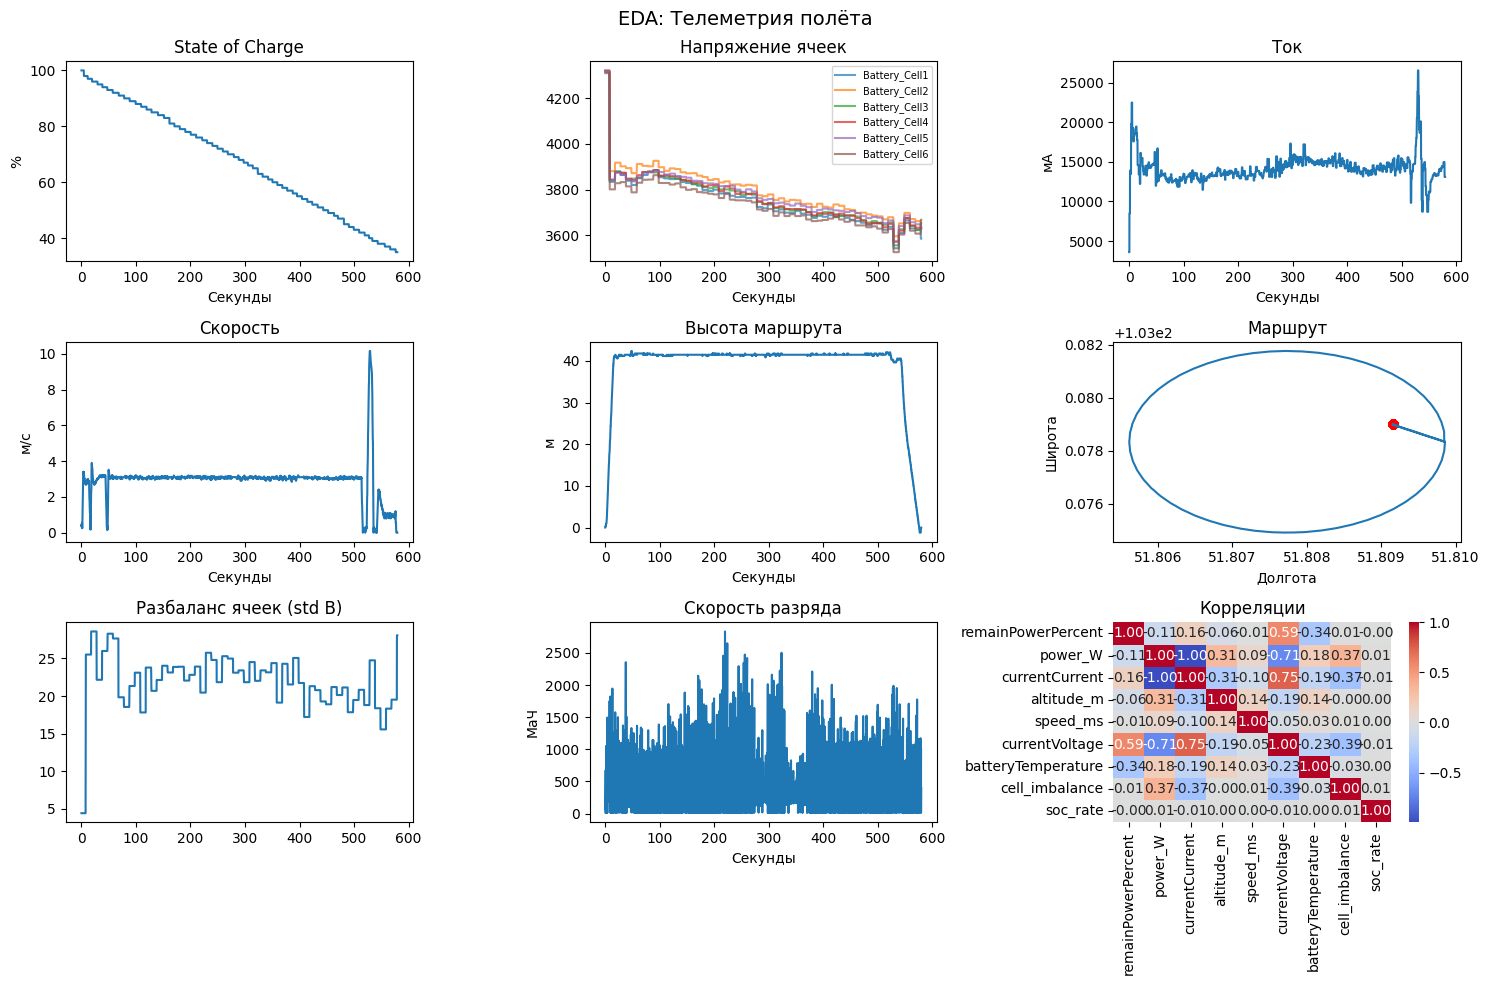

In [ ]:
df_0 = df[df['file_id'] == 395]
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
fig.suptitle('EDA: Телеметрия полёта', fontsize=14)

# SOC во времени
axes[0,0].plot(df_0['flight_time_s'], df_0['remainPowerPercent'])
axes[0,0].set_title('State of Charge')
axes[0,0].set_xlabel('Секунды')
axes[0,0].set_ylabel('%')

# Напряжение ячеек
for col in cell_cols:
    axes[0,1].plot(df_0['flight_time_s'], df_0[col], alpha=0.7, label=col)
axes[0,1].set_title('Напряжение ячеек')
axes[0,1].set_xlabel('Секунды')
axes[0,1].legend(fontsize=7)

# Ток потребления
axes[0,2].plot(df_0['flight_time_s'], df_0['current_mA'])
axes[0,2].set_title('Ток')
axes[0,2].set_xlabel('Секунды')
axes[0,2].set_ylabel('мА')

# Скорость
axes[1,0].plot(df_0['flight_time_s'], df_0['speed_ms'])
axes[1,0].set_title('Скорость')
axes[1,0].set_ylabel('м/с')
axes[1,0].set_xlabel('Секунды')


# Высота
axes[1,1].plot(df_0['flight_time_s'], df_0['altitude_m'])
axes[1,1].set_title('Высота маршрута')
axes[1,1].set_ylabel('м')
axes[1,1].set_xlabel('Секунды')

# Маршрут
axes[1,2].plot(df_0['latitude'], df_0['longitude'])
axes[1,2].scatter(df_0['home_latitude'], df_0['home_longitude'], c='red')
axes[1,2].set_title('Маршрут')
axes[1,2].set_ylabel('Широта')
axes[1,2].set_xlabel('Долгота')

# Разбаланс ячеек
axes[2,0].plot(df_0['flight_time_s'], df_0['cell_imbalance'])
axes[2,0].set_title('Разбаланс ячеек (std В)')

# скорость разряда
# ax2 = axes[2, 1].twinx()
axes[2,1].plot(df_0['flight_time_s'], df_0['soc_rate'])
# ax2.plot(df['flight_time_s'], df['altitude_m'])
axes[2,1].set_title('Скорость разряда')
axes[2,1].set_ylabel('МаЧ')
axes[2,1].set_xlabel('Секунды')

# Корреляции
key_cols = ['remainPowerPercent', 'power_W', 'currentCurrent',
            'altitude_m', 'speed_ms', 'currentVoltage',
            'batteryTemperature', 'cell_imbalance', 'soc_rate']
corr = df[key_cols].corr()
sns.heatmap(corr, ax=axes[2,2], annot=True, fmt='.2f',
            cmap='coolwarm', center=0)
axes[2,2].set_title('Корреляции')

plt.tight_layout()
plt.savefig('eda_flight.png', dpi=150)
plt.show()

/tmp/ipykernel_636/4286222146.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['soc_rate_smooth'] = df['soc_rate'].rolling(
/tmp/ipykernel_636/4286222146.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['remaining_time_s'] = (


Text(0.5, 1.0, 'SOC vs Расчётное оставшееся время полёта')

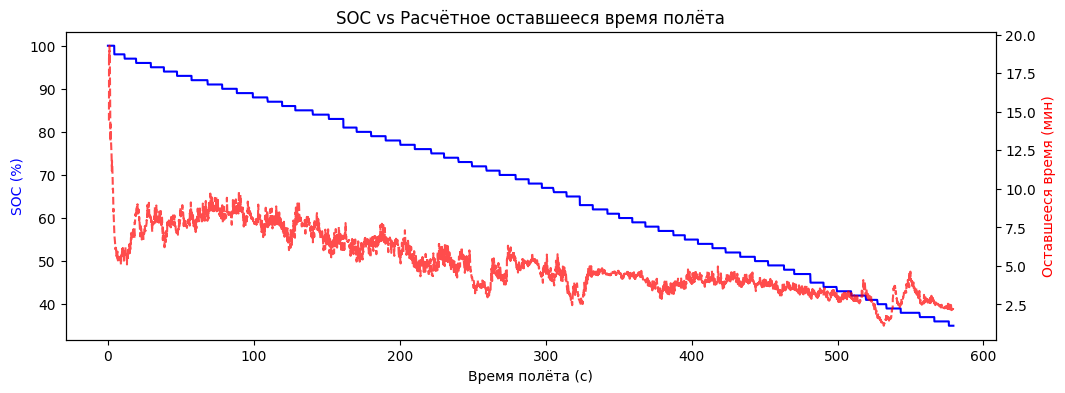

In [ ]:
def estimate_remaining_time(df):
    # Скользящее среднее скорости разряда (% в секунду)
    window = 30  # секунд
    df['soc_rate_smooth'] = df['soc_rate'].rolling(
        window, min_periods=5).mean().abs()

    df['remaining_time_s'] = (
        (df['currentElectricity'] - df['soc_rate_smooth']) / df['soc_rate_smooth'] * 60
    )
    return df

df = estimate_remaining_time(df)
df_0 = estimate_remaining_time(df_0)
fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.plot(df_0['flight_time_s'], df_0['remainPowerPercent'],
         'b-', label='SOC (%)')
ax2 = ax1.twinx()
ax2.plot(df_0['flight_time_s'], df_0['remaining_time_s']/60,
         'r--', label='Остаток (мин)', alpha=0.7)
ax1.set_xlabel('Время полёта (с)')
ax1.set_ylabel('SOC (%)', color='b')
ax2.set_ylabel('Оставшееся время (мин)', color='r')
plt.title('SOC vs Расчётное оставшееся время полёта')

In [ ]:
print(df.columns.values)

['latitude' 'longitude' 'altitude(feet)' 'ascent(feet)' 'speed(mph)'
 'distance(feet)' 'max_altitude(feet)' 'max_ascent(feet)' 'max_speed(mph)'
 'max_distance(feet)' 'time(millisecond)' 'datetime(utc)'
 'datetime(local)' 'satellites' 'pressure(Pa)' 'temperature(F)'
 'voltage(v)' 'home_latitude' 'home_longitude' 'velocityX(mph)'
 'velocityY(mph)' 'velocityZ(mph)' 'pitch(deg)' 'roll(deg)' 'yaw(deg)'
 'powerlevel' 'isflying' 'istakingphoto' 'remainPowerPercent'
 'remainLifePercent' 'currentCurrent' 'currentElectricity'
 'currentVoltage' 'batteryTemperature' 'dischargeCount' 'flightmode'
 'isMotorsOn' 'isTakingVideo' 'Rc_elevator' 'Rc_aileron' 'Rc_throttle'
 'Rc_rudder' 'Rc_gyro' 'timestamp' 'Battery_Cell1' 'Battery_Cell2'
 'Battery_Cell3' 'Battery_Cell4' 'Battery_Cell5' 'Battery_Cell6'
 'Dronetype' 'AppVersion' 'Planename' 'FlyControllerSerialNumber'
 'RemoteSerialNumber' 'BatterySerialNumber' 'CENTER_BATTERY.productDate'
 'CENTER_BATTERY.serialNo' 'CENTER_BATTERY.fullCapacity'
 'CENTER_B

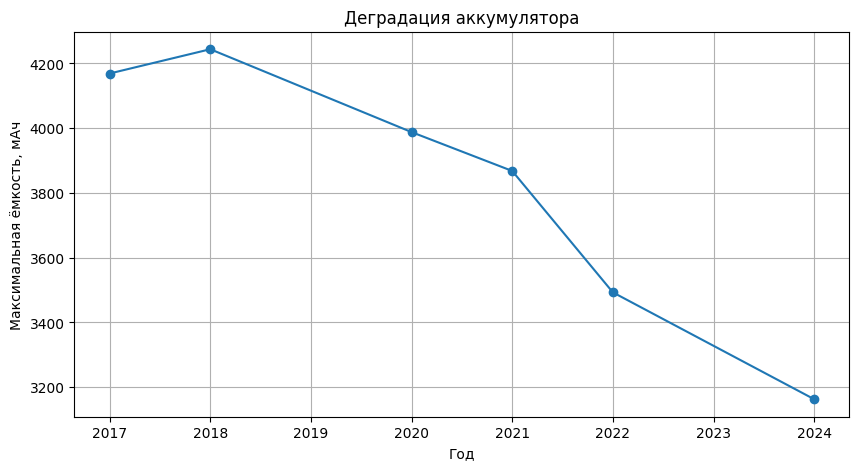

In [ ]:
df['year'] = pd.to_datetime(df['datetime(utc)']).dt.year

year_capacity = (
    df.groupby('year')['currentElectricity']
      .max()
      .reset_index()
)

plt.figure(figsize=(10, 5))

plt.plot(
    year_capacity['year'],
    year_capacity['currentElectricity'],
    marker='o'
)

plt.xlabel('Год')
plt.ylabel('Максимальная ёмкость, мАч')
plt.title('Деградация аккумулятора')
plt.grid(True)

plt.show()

# Машинное обучение

## Baseline

In [ ]:
df['file_id'].max()

397

In [ ]:
df['mode_code'] = df['flightmode'].astype('category').cat.codes
FEATURES = [
    # 'voltage_V',
    # 'current_A',
    # 'power_W',
    'cell_imbalance_mV',
    'altitude_m',
    'pitch(deg)',
    'roll(deg)',
    'mode_code',
    'velocityX(mph)',
    'velocityY(mph)',
    'velocityZ(mph)',
    'flight_time_s'
]

train_df = df[df['file_id'] < 390]
test_df = df[df['file_id'] >= 390]

df_clean = train_df[FEATURES + ['soc_rate_smooth']].dropna().copy()

In [ ]:
def create_sequences(X, y, window_size=15):
    """Создание последовательностей для LSTM"""
    X_seq, y_seq = [], []
    for i in range(window_size, len(X)):
        X_seq.append(X[i-window_size:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

WINDOW_SIZE = 15

X_raw = df_clean[FEATURES].values
y_raw = df_clean['soc_rate_smooth'].values

# Нормализация признаков
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X_raw)
y_scaled = scaler_y.fit_transform(y_raw.reshape(-1, 1)).flatten()

# Создание последовательностей
X_seq, y_seq = create_sequences(X_scaled, y_scaled, WINDOW_SIZE)

split_idx = int(len(X_seq) * 0.8)
X_train, X_test = X_seq[:split_idx], X_seq[split_idx:]
y_train, y_test = y_seq[:split_idx], y_seq[split_idx:]

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"SoC range: train [{y_train.min():.1f}, {y_train.max():.1f}]%")

Train: (925213, 15, 9), Test: (231304, 15, 9)
SoC range: train [-0.2, 195.6]%


In [ ]:
input_shape=(WINDOW_SIZE, len(FEATURES))
model = tf.keras.Sequential([
        layers.LSTM(50, return_sequences=True,
                    input_shape=input_shape,
                    kernel_initializer='he_normal'),
        layers.LSTM(50, return_sequences=True,
                    kernel_initializer='he_normal'),
        layers.LSTM(50, kernel_initializer='he_normal'),
        layers.Dense(50, activation='relu', kernel_initializer='he_normal'),
        layers.Dense(1, activation='linear')
    ], name='soc_lstm_baseline')

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='huber',  # устойчив к шуму телеметрии
    metrics=[
        'mae',
        'mse',
        tf.keras.metrics.RootMeanSquaredError(name='rmse')
    ]
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "soc_lstm_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 15, 50)         │        12,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 15, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,001 (214.85 KB)

 Trainable params: 55,001 (214.85 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cb = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    mode='min',
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=8,
    min_lr=1e-6,
    verbose=1
)

history_lstm = model.fit(
    X_train, y_train,
    batch_size=512,
    epochs=100,
    validation_split=0.15,
    callbacks=[cb, reduce_lr],
    verbose=1
)

y_pred_scaled = model.predict(X_test, verbose=0).flatten()
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_true = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()

# Метрики
mae = np.mean(np.abs(y_true - y_pred))
rmse = np.sqrt(np.mean((y_true - y_pred)**2))
max_err = np.max(np.abs(y_true - y_pred))
r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - y_true.mean())**2)

print(f"\nРезультаты на тесте:")
print(f"   MAE: {mae:.2f}")
print(f"   RMSE: {rmse:.2f}")
print(f"   Max Error: {max_err:.2f}")
print(f"   R2: {r2:.4f}")


Epoch 1/100
1536/1536 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 0.0045 - mae: 0.0217 - mse: 0.7765 - rmse: 0.8812 - val_loss: 0.0014 - val_mae: 0.0267 - val_mse: 0.0028 - val_rmse: 0.0533 - learning_rate: 0.0010
Epoch 2/100
1536/1536 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - loss: 0.0045 - mae: 0.0215 - mse: 0.7749 - rmse: 0.8803 - val_loss: 0.0012 - val_mae: 0.0268 - val_mse: 0.0025 - val_rmse: 0.0498 - learning_rate: 0.0010
Epoch 3/100
1536/1536 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - loss: 0.0045 - mae: 0.0216 - mse: 0.7770 - rmse: 0.8815 - val_loss: 0.0015 - val_mae: 0.0270 - val_mse: 0.0029 - val_rmse: 0.0542 - learning_rate: 0.0010
Epoch 4/100
1536/1536 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - loss: 0.0045 - mae: 0.0212 - mse: 0.7772 - rmse: 0.8816 - val_loss: 0.0015 - val_mae: 0.0271 - val_mse: 0.0031 - val_rmse: 0.0560 - learning_rate: 0.0010
Epoch 5/100
1536/1536 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - loss: 0.0045 - mae: 0.0210 - mse: 0.7764 - rmse: 0.8812 - val_loss: 0.0018 - val_mae: 0.0

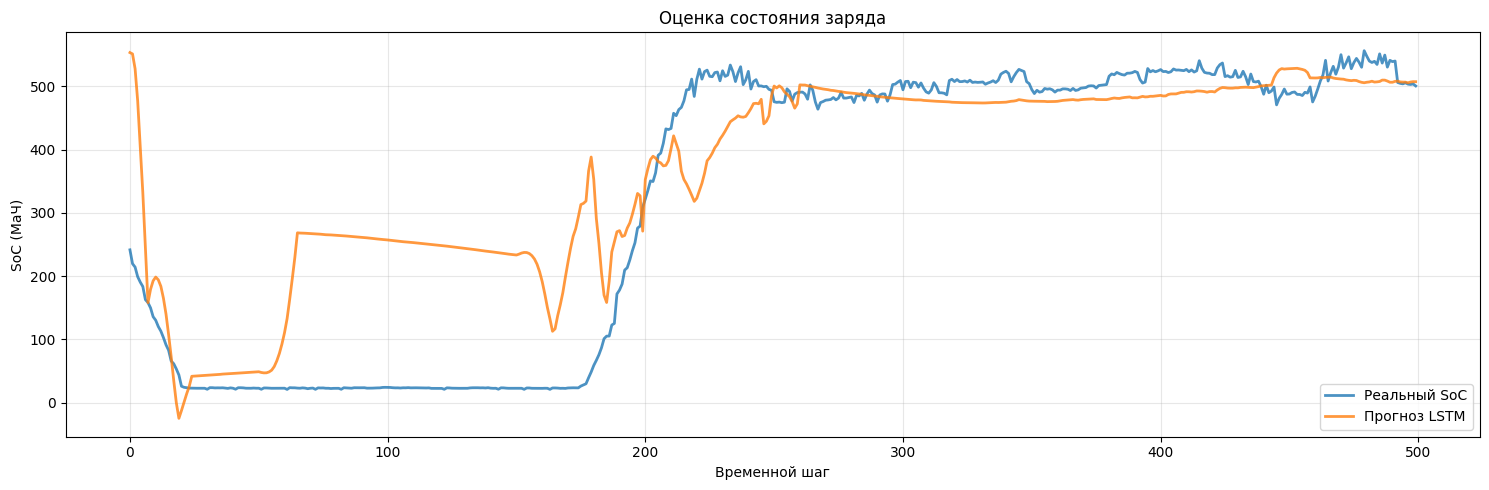

In [ ]:
plt.figure(figsize=(15, 5))

plt.plot(y_true[100000:100500], label='Реальный SoC', linewidth=2, alpha=0.8)
plt.plot(y_pred[100000:100500], label='Прогноз LSTM', linewidth=2, alpha=0.8)
plt.xlabel('Временной шаг')
plt.ylabel('SoC (МаЧ)')
plt.title('Оценка состояния заряда')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

In [ ]:
def estimate_remaining_flight(soc_current, soc_pred_trajectory,
                             current_A_avg, capacity_Ah=5.2,
                             safety_margin=0.2):
    soc_forecast = np.percentile(soc_pred_trajectory, 25)
    usable_soc = max(0, soc_current/100 - safety_margin)

    if current_A_avg < 0.01:
        return 999
    remaining_minutes = (usable_soc * capacity_Ah) / (current_A_avg / 60)
    return remaining_minutes

In [ ]:
print(model.predict(X_train))
print(y_train)

28913/28913 ━━━━━━━━━━━━━━━━━━━━ 88s 3ms/step
[[-0.0658127 ]
 [-0.06878027]
 [-0.06220747]
 ...
 [-0.00629123]
 [ 0.00069021]
 [ 0.00418314]]
[-9.60434998e-03 -1.18151180e-02 -1.87222712e-02 ...  2.69125703e-04
  1.10244851e-05  5.51550309e-04]


In [ ]:
model.evaluate(X_test, y_test)

7229/7229 ━━━━━━━━━━━━━━━━━━━━ 38s 5ms/step - loss: 0.0028 - mae: 0.0362 - mse: 0.0128 - rmse: 0.1133


[0.0027772006578743458,
 0.03618663549423218,
 0.012833665125072002,
 0.11328576505184174]

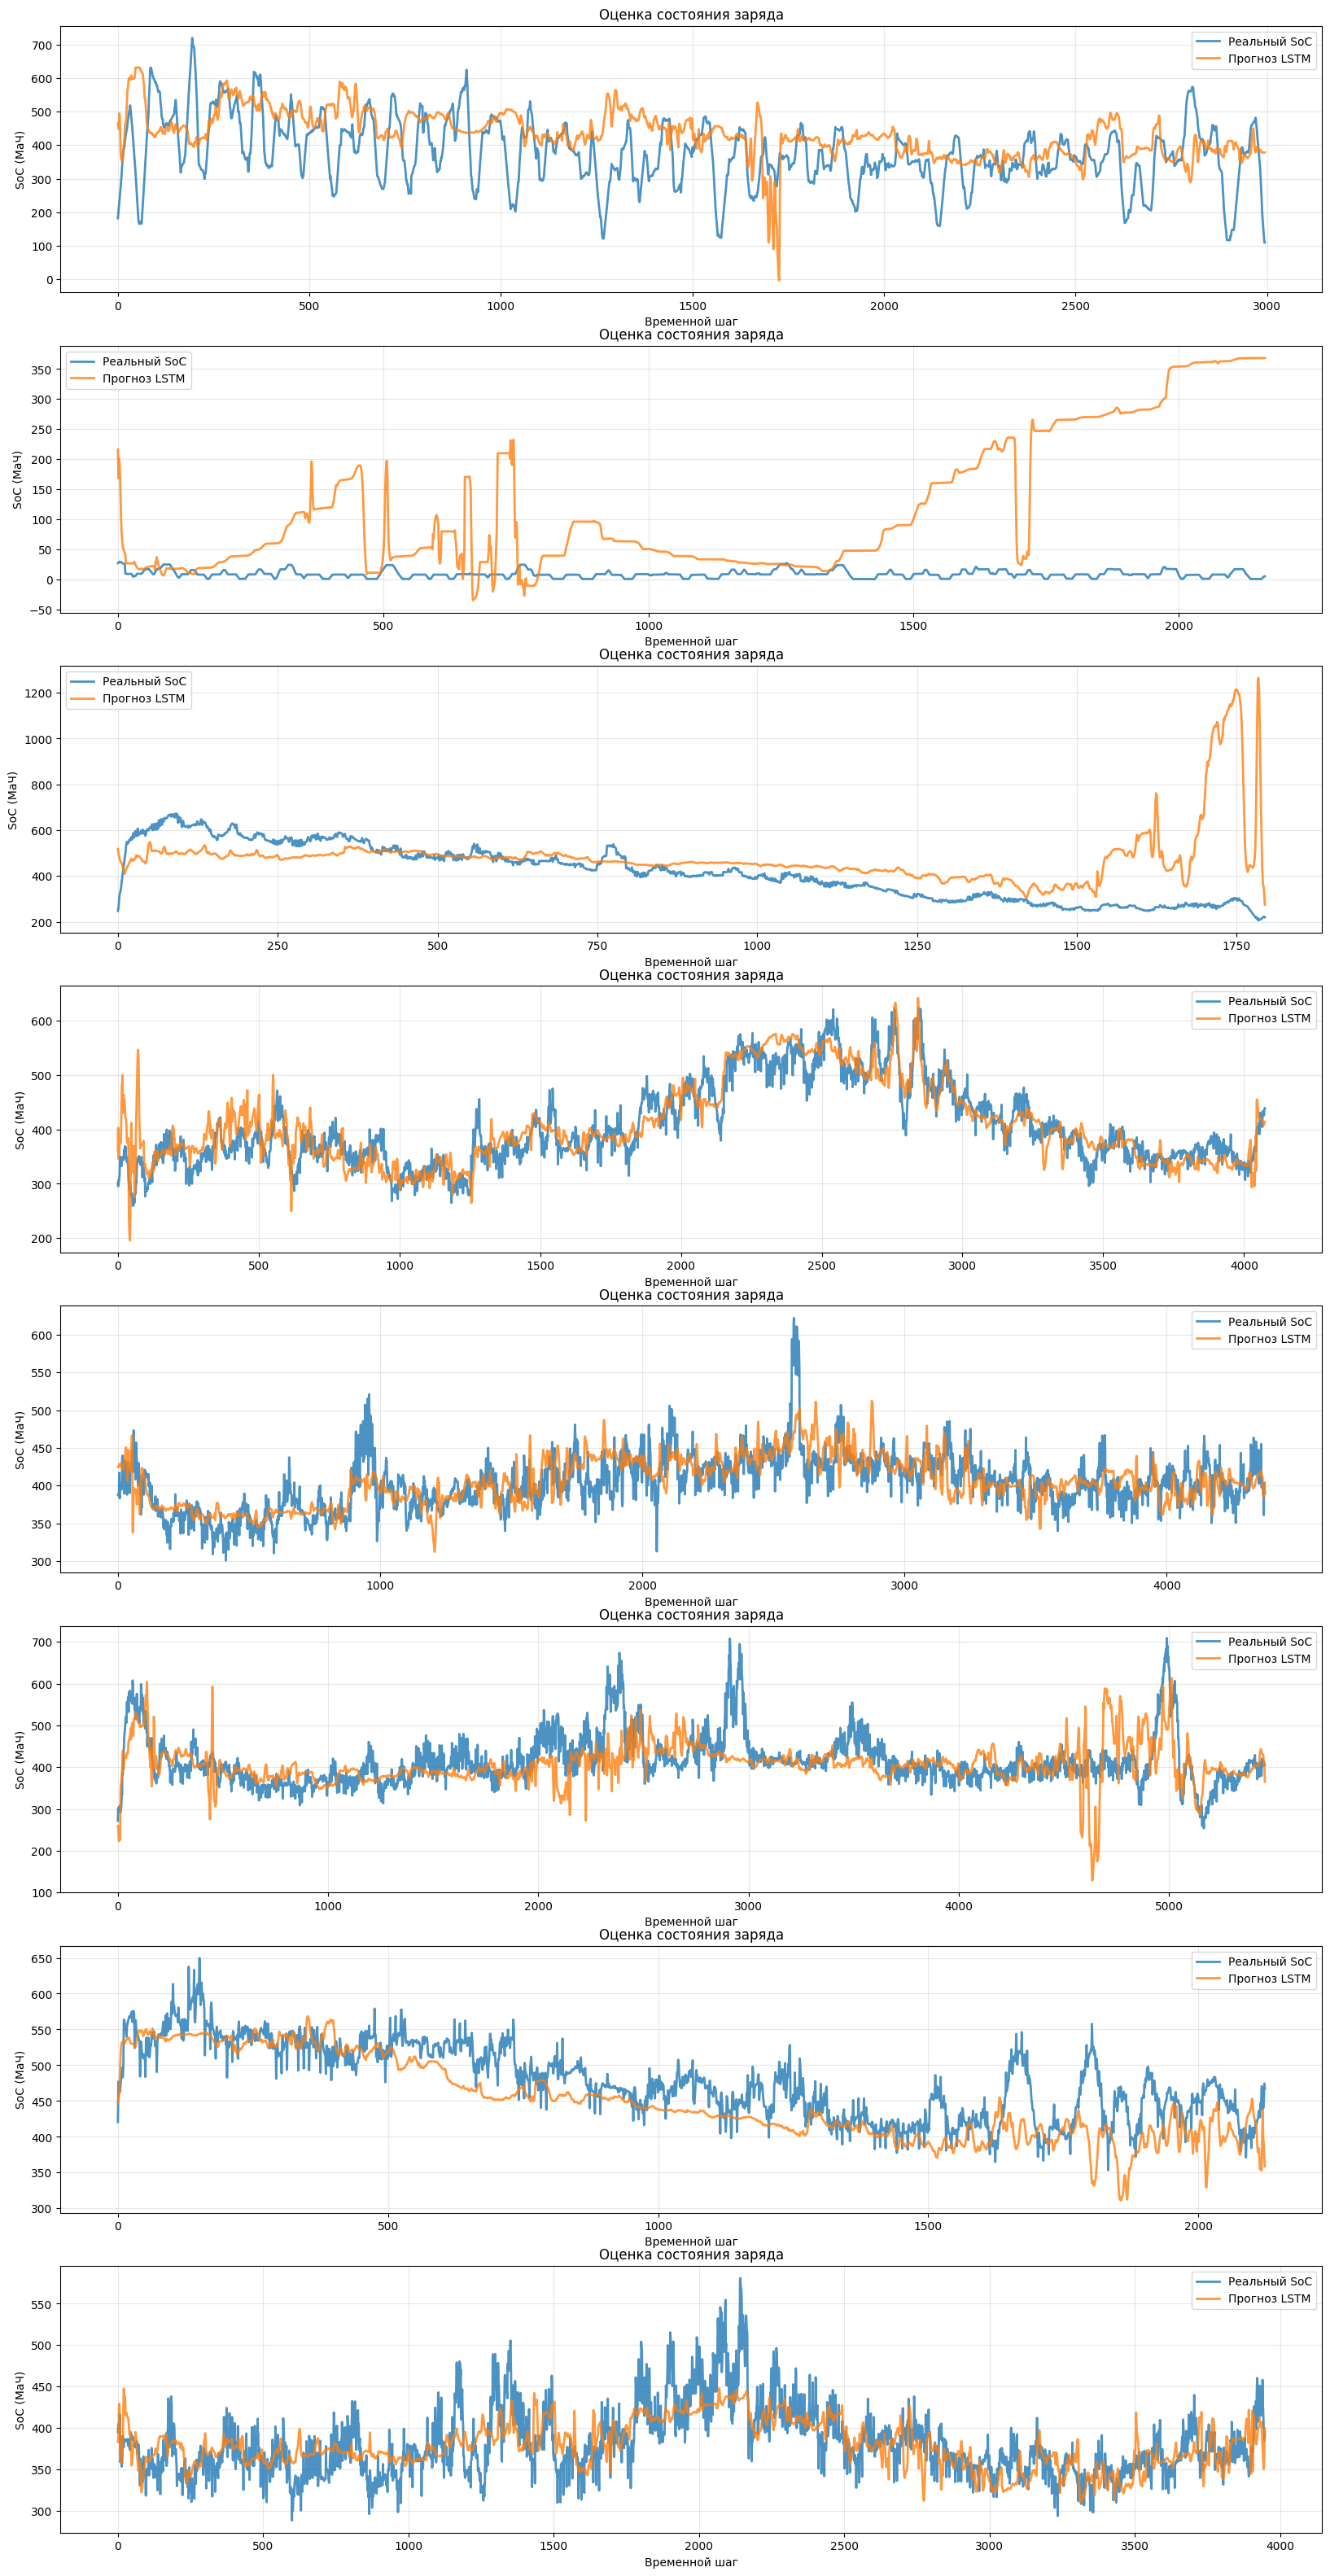

In [ ]:
charts = test_df['file_id'].unique()
fig, axes = plt.subplots(8, 1, figsize=(20, 40))
# fig.suptitle('EDA: Телеметрия полёта', fontsize=14)

for idx, file_id in enumerate(test_df['file_id'].unique()):
    X_test_df = test_df[test_df['file_id'] == file_id][FEATURES].values
    y_test_df = test_df[test_df['file_id'] == file_id]['soc_rate_smooth'].values

    X_file_scaled = scaler_X.transform(X_test_df)
    y_file_scaled = scaler_y.transform(y_test_df.reshape(-1, 1)).flatten()

    X_seq, y_seq = create_sequences(X_file_scaled, y_file_scaled, WINDOW_SIZE)

    y_pred_scaled = model.predict(X_seq, verbose=0).flatten()

    y_true = scaler_y.inverse_transform(y_seq.reshape(-1, 1)).flatten()
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

    axes[idx].plot(y_true, label='Реальный SoC', linewidth=2, alpha=0.8)
    # axes[idx].plot(y_test_df['soc_rate_smooth'].values)
    axes[idx].plot(y_pred, label='Прогноз LSTM', linewidth=2, alpha=0.8)
    axes[idx].set_xlabel('Временной шаг')
    axes[idx].set_ylabel('SoC (МаЧ)')
    axes[idx].set_title('Оценка состояния заряда')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

# Модификация с Attention

In [ ]:
inp = layers.Input(shape=(WINDOW_SIZE, len(FEATURES)))

x = layers.LSTM(50, return_sequences=True,
                kernel_initializer='he_normal')(inp)
x = layers.LSTM(50, return_sequences=True,
                kernel_initializer='he_normal')(x)
x = layers.LSTM(50, return_sequences=True,
                kernel_initializer='he_normal')(x)
attention = layers.Attention()([x, x])

x = layers.Add()([x, attention])
x = layers.LayerNormalization()(x)

x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(50, activation='relu',
                  kernel_initializer='he_normal')(x)
x = layers.Dropout(0.2)(x)
out = layers.Dense(1, activation='linear')(x)
model = tf.keras.Model(inputs=inp, outputs=out, name='soc_lstm_attention')

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='huber',
    metrics=['mae', 'mse', tf.keras.metrics.RootMeanSquaredError(name='rmse')]
)

model.summary()

Model: "soc_lstm_attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 15, 9)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 15, 50)    │     12,000 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_4 (LSTM)       │ (None, 15, 50)    │     20,200 │ lstm_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_5 (LSTM)       │ (None, 15, 50)    │     20,200 │ lstm_4[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 15, 50)    │          0 │ lstm_5[0][0],     │
│ (Attention)         │                   │            │ lstm_5[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 15, 50)    │          0 │ lstm_5[0][0],     │
│                     │                   │            │ attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 15, 50)    │        100 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 50)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 50)        │      2,550 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 50)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         51 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 55,101 (215.24 KB)

 Trainable params: 55,101 (215.24 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cb = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    mode='min',
    verbose=1
)

history_lstm_attention = model.fit(
    X_train, y_train,
    batch_size=512,
    epochs=100,
    validation_split=0.15,
    callbacks=[cb, lr],
    verbose=1
)

y_pred_scaled = model.predict(X_test, verbose=0).flatten()
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_true = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()

# Метрики
mae = np.mean(np.abs(y_true - y_pred))
rmse = np.sqrt(np.mean((y_true - y_pred)**2))
max_err = np.max(np.abs(y_true - y_pred))
r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - y_true.mean())**2)

print(f"\nРезультаты на тесте:")
print(f"   MAE: {mae:.2f}")
print(f"   RMSE: {rmse:.2f}")
print(f"   Max Error: {max_err:.2f}")
print(f"   R2: {r2:.4f}")


Epoch 1/100
1536/1536 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - loss: 0.0147 - mae: 0.0641 - mse: 1.4755 - rmse: 1.2147 - val_loss: 0.0013 - val_mae: 0.0310 - val_mse: 0.0026 - val_rmse: 0.0506
Epoch 2/100
1536/1536 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - loss: 0.0094 - mae: 0.0433 - mse: 1.4632 - rmse: 1.2096 - val_loss: 0.0012 - val_mae: 0.0295 - val_mse: 0.0024 - val_rmse: 0.0493
Epoch 3/100
1536/1536 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - loss: 0.0092 - mae: 0.0407 - mse: 1.4627 - rmse: 1.2094 - val_loss: 0.0012 - val_mae: 0.0282 - val_mse: 0.0023 - val_rmse: 0.0484
Epoch 4/100
1536/1536 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - loss: 0.0090 - mae: 0.0391 - mse: 1.4624 - rmse: 1.2093 - val_loss: 0.0012 - val_mae: 0.0288 - val_mse: 0.0025 - val_rmse: 0.0495
Epoch 5/100
1536/1536 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 0.0089 - mae: 0.0377 - mse: 1.4621 - rmse: 1.2092 - val_loss: 0.0013 - val_mae: 0.0286 - val_mse: 0.0025 - val_rmse: 0.0500
Epoch 6/100
1536/1536 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/ste

In [ ]:
model.evaluate(X_test, y_test)

7229/7229 ━━━━━━━━━━━━━━━━━━━━ 38s 5ms/step - loss: 0.0019 - mae: 0.0346 - mse: 0.0038 - rmse: 0.0615


[0.001882248790934682,
 0.03464103862643242,
 0.003783221123740077,
 0.06150789558887482]

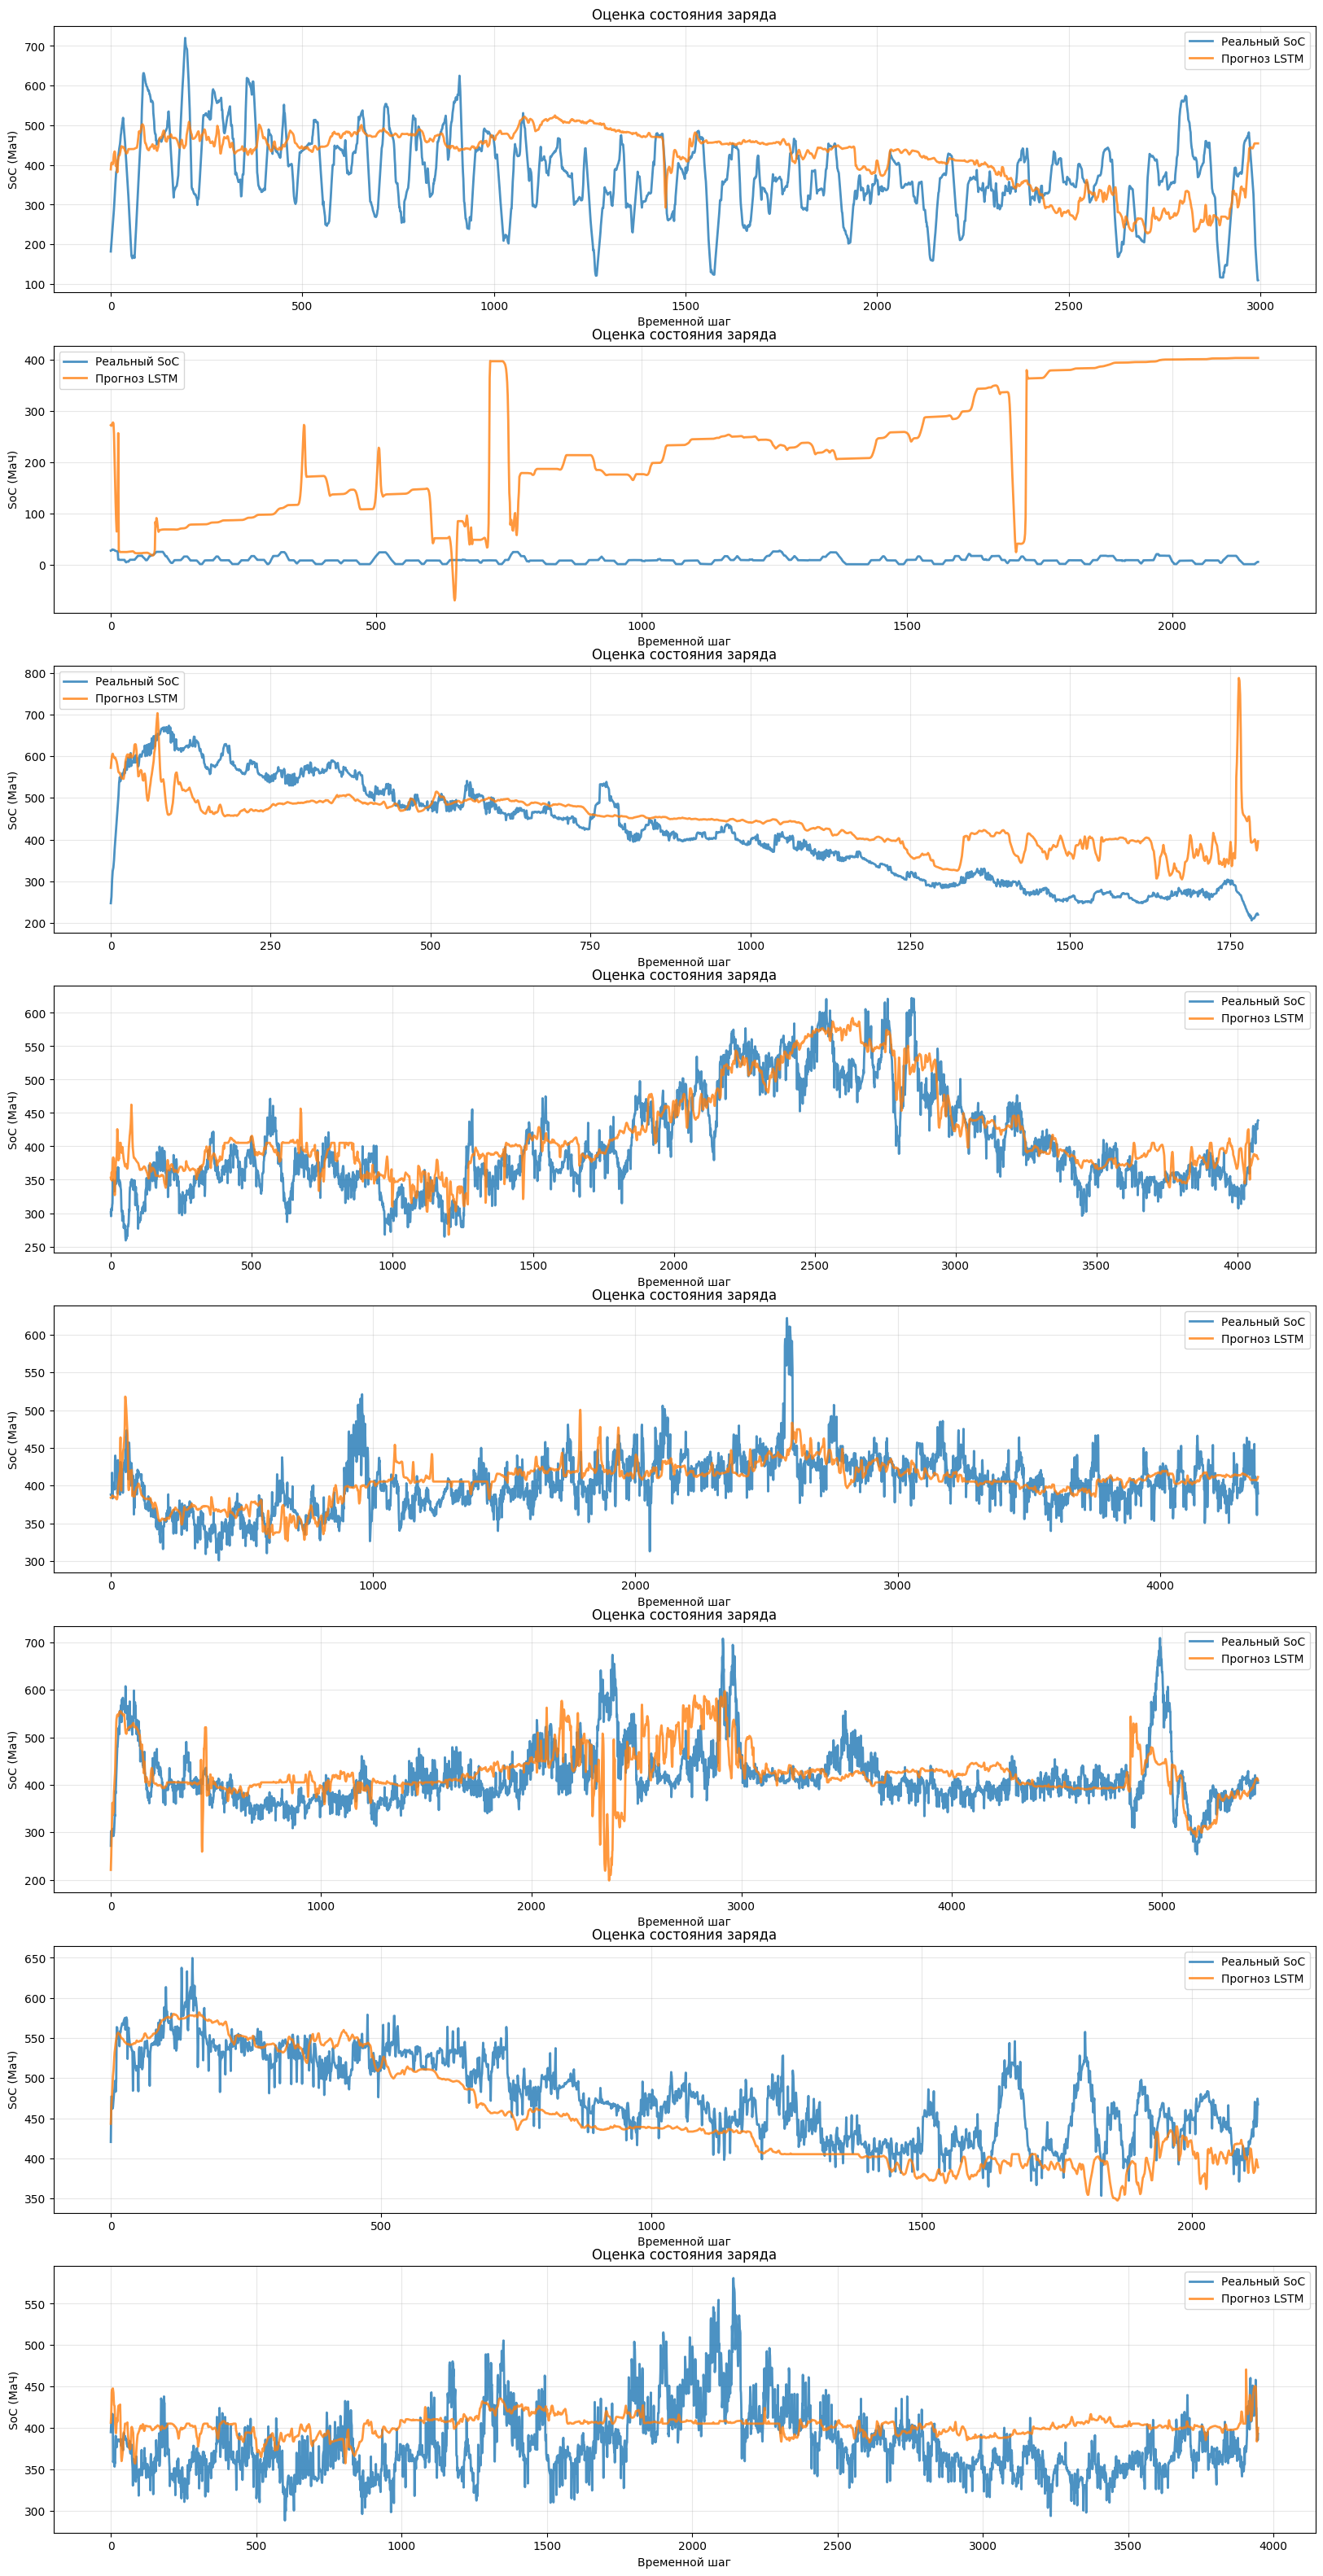

In [ ]:
charts = test_df['file_id'].unique()
fig, axes = plt.subplots(8, 1, figsize=(20, 40))
# fig.suptitle('EDA: Телеметрия полёта', fontsize=14)

for idx, file_id in enumerate(test_df['file_id'].unique()):
    X_test_df = test_df[test_df['file_id'] == file_id][FEATURES].values
    y_test_df = test_df[test_df['file_id'] == file_id]['soc_rate_smooth'].values

    X_file_scaled = scaler_X.transform(X_test_df)
    y_file_scaled = scaler_y.transform(y_test_df.reshape(-1, 1)).flatten()

    X_seq, y_seq = create_sequences(X_file_scaled, y_file_scaled, WINDOW_SIZE)

    y_pred_scaled = model.predict(X_seq, verbose=0).flatten()

    y_true = scaler_y.inverse_transform(y_seq.reshape(-1, 1)).flatten()
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

    axes[idx].plot(y_true, label='Реальный SoC', linewidth=2, alpha=0.8)
    # axes[idx].plot(y_test_df['soc_rate_smooth'].values)
    axes[idx].plot(y_pred, label='Прогноз LSTM', linewidth=2, alpha=0.8)
    axes[idx].set_xlabel('Временной шаг')
    axes[idx].set_ylabel('SoC (МаЧ)')
    axes[idx].set_title('Оценка состояния заряда')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

# Multi head attention

In [ ]:
inp = layers.Input(shape=(WINDOW_SIZE, len(FEATURES)))

x = layers.Bidirectional(  # для лучшего контекста
    layers.LSTM(64, return_sequences=True)
)(inp)

attn = layers.MultiHeadAttention(
    num_heads=4,
    key_dim=16
)(x, x)

x = layers.Add()([x, attn])
x = layers.LayerNormalization()(x)

x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.2)(x)

x = layers.GlobalAveragePooling1D()(x)
out = layers.Dense(1)(x)

model = tf.keras.Model(inputs=inp, outputs=out, name='soc_lstm_multihead_attention')

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='huber',
    metrics=['mae', 'mse', tf.keras.metrics.RootMeanSquaredError(name='rmse')]
)

model.summary()

Model: "soc_lstm_multihead_attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 15, 9)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 15, 128)   │     37,888 │ input_layer_3[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 15, 128)   │     33,088 │ bidirectional_1[… │
│ (MultiHeadAttentio… │                   │            │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 15, 128)   │          0 │ bidirectional_1[… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 15, 128)   │        256 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 15, 64)    │      8,256 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 15, 64)    │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ dropout_6[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 1)         │         65 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 79,553 (310.75 KB)

 Trainable params: 79,553 (310.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cb = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    mode='min',
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=8,
    min_lr=1e-6,
    verbose=1
)

history_multi_attention = model.fit(
    X_train, y_train,
    batch_size=512,
    epochs=100,
    validation_split=0.15,
    callbacks=[cb, reduce_lr],
    verbose=1
)

y_pred_scaled = model.predict(X_test, verbose=0).flatten()
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_true = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()

mae = np.mean(np.abs(y_true - y_pred))
rmse = np.sqrt(np.mean((y_true - y_pred)**2))
max_err = np.max(np.abs(y_true - y_pred))
r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - y_true.mean())**2)

print(f"\nРезультаты на тесте:")
print(f"   MAE: {mae:.2f}")
print(f"   RMSE: {rmse:.2f}")
print(f"   Max Error: {max_err:.2f}")
print(f"   R2: {r2:.4f}")


Epoch 1/100
1536/1536 ━━━━━━━━━━━━━━━━━━━━ 31s 18ms/step - loss: 0.0113 - mae: 0.0561 - mse: 1.4670 - rmse: 1.2112 - val_loss: 0.0011 - val_mae: 0.0295 - val_mse: 0.0022 - val_rmse: 0.0473 - learning_rate: 0.0010
Epoch 2/100
1536/1536 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - loss: 0.0091 - mae: 0.0395 - mse: 1.4622 - rmse: 1.2092 - val_loss: 0.0011 - val_mae: 0.0283 - val_mse: 0.0022 - val_rmse: 0.0469 - learning_rate: 0.0010
Epoch 3/100
1536/1536 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - loss: 0.0090 - mae: 0.0382 - mse: 1.4620 - rmse: 1.2091 - val_loss: 9.9906e-04 - val_mae: 0.0269 - val_mse: 0.0020 - val_rmse: 0.0447 - learning_rate: 0.0010
Epoch 4/100
1536/1536 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - loss: 0.0089 - mae: 0.0373 - mse: 1.4618 - rmse: 1.2091 - val_loss: 0.0010 - val_mae: 0.0277 - val_mse: 0.0021 - val_rmse: 0.0453 - learning_rate: 0.0010
Epoch 5/100
1536/1536 ━━━━━━━━━━━━━━━━━━━━ 27s 18ms/step - loss: 0.0088 - mae: 0.0362 - mse: 1.4609 - rmse: 1.2087 - val_loss: 0.0012 - val_mae:

In [ ]:
model.evaluate(X_test, y_test)

7229/7229 ━━━━━━━━━━━━━━━━━━━━ 36s 5ms/step - loss: 0.0017 - mae: 0.0338 - mse: 0.0034 - rmse: 0.0584


[0.001697136671282351,
 0.03384656459093094,
 0.003413918660953641,
 0.058428749442100525]

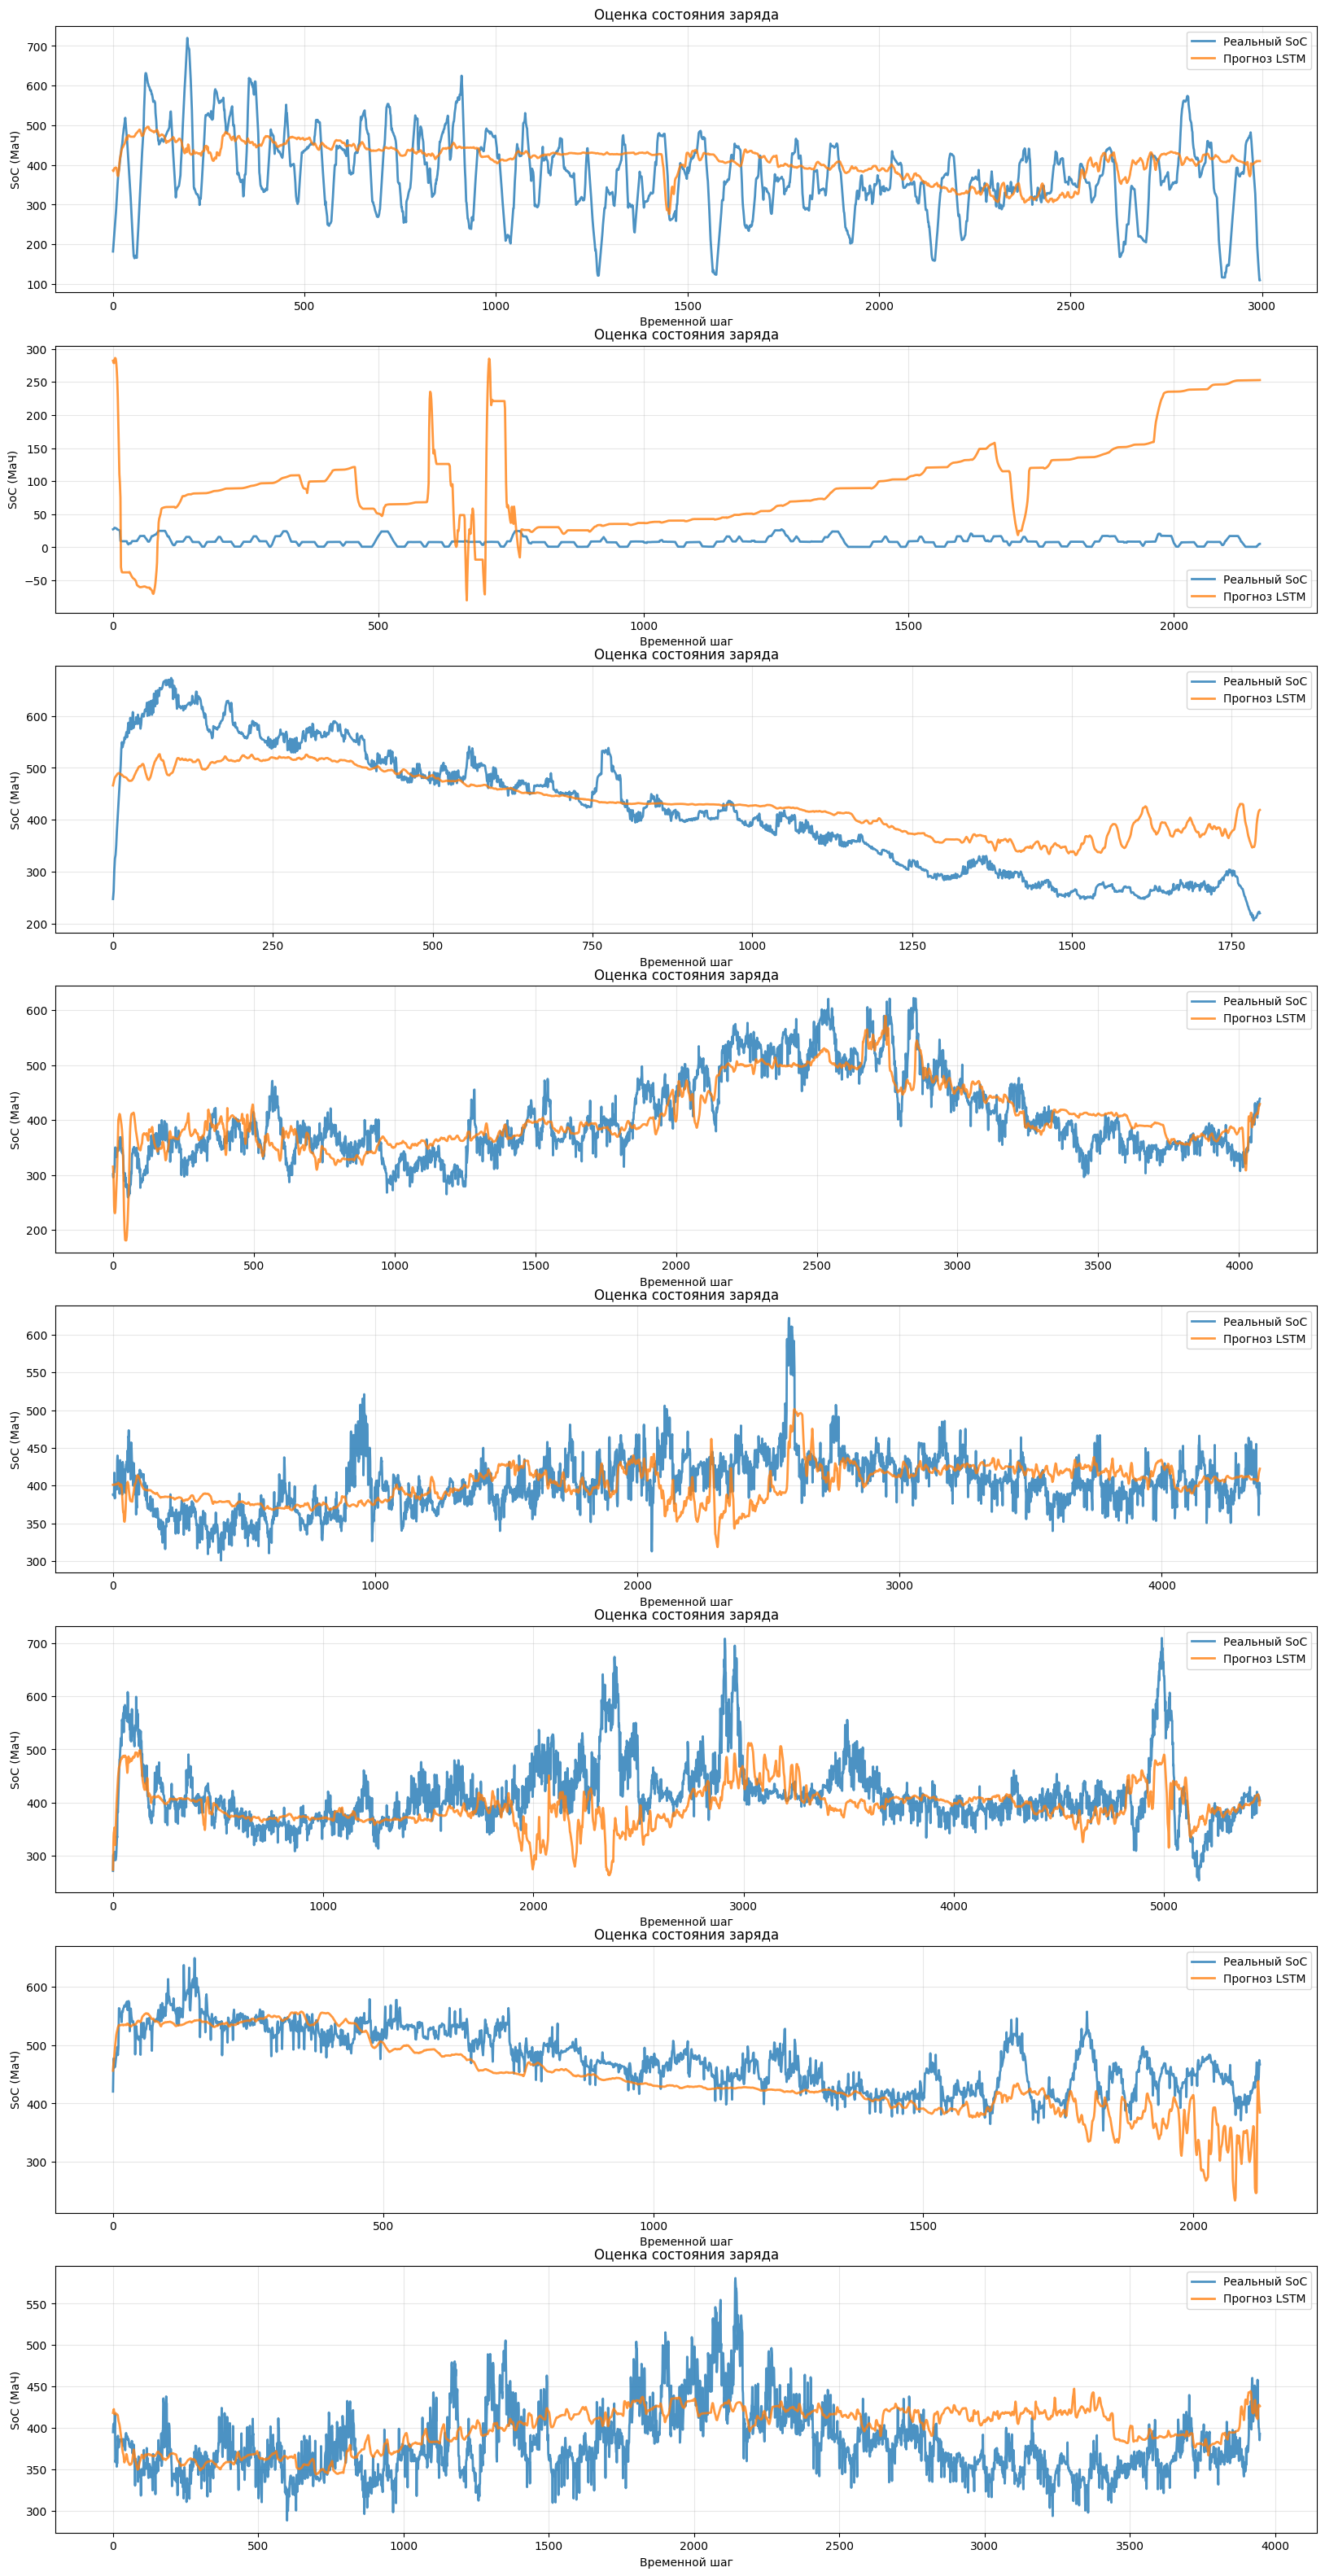

In [ ]:
charts = test_df['file_id'].unique()
fig, axes = plt.subplots(8, 1, figsize=(20, 40))
# fig.suptitle('EDA: Телеметрия полёта', fontsize=14)

for idx, file_id in enumerate(test_df['file_id'].unique()):
    X_test_df = test_df[test_df['file_id'] == file_id][FEATURES].values
    y_test_df = test_df[test_df['file_id'] == file_id]['soc_rate_smooth'].values

    X_file_scaled = scaler_X.transform(X_test_df)
    y_file_scaled = scaler_y.transform(y_test_df.reshape(-1, 1)).flatten()

    X_seq, y_seq = create_sequences(X_file_scaled, y_file_scaled, WINDOW_SIZE)

    y_pred_scaled = model.predict(X_seq, verbose=0).flatten()

    y_true = scaler_y.inverse_transform(y_seq.reshape(-1, 1)).flatten()
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

    axes[idx].plot(y_true, label='Реальный SoC', linewidth=2, alpha=0.8)
    # axes[idx].plot(y_test_df['soc_rate_smooth'].values)
    axes[idx].plot(y_pred, label='Прогноз LSTM', linewidth=2, alpha=0.8)
    axes[idx].set_xlabel('Временной шаг')
    axes[idx].set_ylabel('SoC (МаЧ)')
    axes[idx].set_title('Оценка состояния заряда')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

# Seq2Seq

In [ ]:
ROUTE_FEATURES = [
    'altitude_m',
    'speed_ms',
    'velX_ms',
    'velY_ms',
    'velZ_ms',
    'pitch(deg)',
    'roll(deg)',
    'mode_code',
]

TARGET_FEATURES = [
    'soc_rate_smooth',
    'voltage_V',
]

def build_flight_pairs(df, file_ids, seq_len=200):
    """
    Нарезаем каждый полёт на пары (маршрут → потребление)
    фиксированной длины. Как в Seq2Seq для перевода текста.
    seq_len: унифицированная длина = 200 шагов = 20 сек
    """
    X_flights, y_flights = [], []

    for fid in file_ids:
        flight = df[df['file_id'] == fid][
            ROUTE_FEATURES + TARGET_FEATURES
        ].dropna()

        if len(flight) < seq_len:
            continue
        for start in range(0, len(flight) - seq_len, seq_len // 2):
            segment = flight.iloc[start:start + seq_len]
            X_flights.append(segment[ROUTE_FEATURES].values)
            y_flights.append(segment[TARGET_FEATURES].values)

    return np.array(X_flights), np.array(y_flights)

SEQ_LEN = 200

X_flights, y_flights = build_flight_pairs(
    df, df['file_id'].unique(), seq_len=SEQ_LEN
)

# Нормализация
scaler_route  = StandardScaler()
scaler_target = StandardScaler()

N, T, F = X_flights.shape
N, T, P = y_flights.shape

X_norm = scaler_route.fit_transform(
    X_flights.reshape(-1, F)).reshape(N, T, F)
y_norm = scaler_target.fit_transform(
    y_flights.reshape(-1, P)).reshape(N, T, P)

split  = int(N * 0.8)
X_tr, X_te = X_norm[:split], X_norm[split:]
y_tr, y_te = y_norm[:split], y_norm[split:]

In [ ]:
enc_inp = tf.keras.Input(
    shape=(SEQ_LEN, len(ROUTE_FEATURES)), name='route_input'
)
lstm_units=64
enc_out = layers.Bidirectional(
    layers.LSTM(lstm_units, return_sequences=True,
                kernel_initializer='he_normal'),
    name='encoder'
)(enc_inp)

attn_out = layers.MultiHeadAttention(
    num_heads=4, key_dim=lstm_units // 4,
    name='route_attention'
)(enc_out, enc_out)

attn_out = layers.Add()([enc_out, attn_out])
attn_out = layers.LayerNormalization()(attn_out)

dec_out = layers.LSTM(lstm_units, return_sequences=True,
                      kernel_initializer='he_normal',
                      name='decoder')(attn_out)
dec_out = layers.Dropout(0.1)(dec_out)

consumption = layers.TimeDistributed(
    layers.Dense(1), name='soc_rate'
)(dec_out)

voltage = layers.TimeDistributed(
    layers.Dense(1), name='voltage'
)(dec_out)

seq2seq = tf.keras.Model(
    inputs=enc_inp,
    outputs=[consumption, voltage],
    name='seq2seq_uav_battery'
)

seq2seq.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss={'soc_rate': 'huber', 'voltage': 'mse'},
    loss_weights={'soc_rate': 1.0, 'voltage': 0.5},
    metrics={'soc_rate': 'mae', 'voltage': 'mae'}
)

seq2seq.summary()

Model: "seq2seq_uav_battery"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ route_input         │ (None, 200, 8)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder             │ (None, 200, 128)  │     37,376 │ route_input[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ route_attention     │ (None, 200, 128)  │     33,088 │ encoder[0][0],    │
│ (MultiHeadAttentio… │                   │            │ encoder[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 200, 128)  │          0 │ encoder[0][0],    │
│                     │                   │            │ route_attention[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 200, 128)  │        256 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder (LSTM)      │ (None, 200, 64)   │     49,408 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 200, 64)   │          0 │ decoder[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ soc_rate            │ (None, 200, 1)    │         65 │ dropout_4[0][0]   │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ voltage             │ (None, 200, 1)    │         65 │ dropout_4[0][0]   │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 120,258 (469.76 KB)

 Trainable params: 120,258 (469.76 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_seq2seq = seq2seq.fit(
    X_tr,
    {'soc_rate': y_tr[:, :, 0:1],
     'voltage':  y_tr[:, :, 1:2]},
    batch_size=256,
    epochs=100,
    validation_split=0.15,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            patience=15, restore_best_weights=True)
    ]
)

Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 28s 322ms/step - loss: 0.4935 - soc_rate_loss: 0.0602 - soc_rate_mae: 0.2529 - voltage_loss: 0.8656 - voltage_mae: 0.6244 - val_loss: 0.3307 - val_soc_rate_loss: 0.0159 - val_soc_rate_mae: 0.1247 - val_voltage_loss: 0.7591 - val_voltage_mae: 0.5293
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 207ms/step - loss: 0.3326 - soc_rate_loss: 0.0277 - soc_rate_mae: 0.1610 - voltage_loss: 0.6091 - voltage_mae: 0.4955 - val_loss: 0.2929 - val_soc_rate_loss: 0.0102 - val_soc_rate_mae: 0.0935 - val_voltage_loss: 0.6761 - val_voltage_mae: 0.4814
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 197ms/step - loss: 0.2798 - soc_rate_loss: 0.0223 - soc_rate_mae: 0.1361 - voltage_loss: 0.5144 - voltage_mae: 0.4443 - val_loss: 0.2943 - val_soc_rate_loss: 0.0078 - val_soc_rate_mae: 0.0814 - val_voltage_loss: 0.6677 - val_voltage_mae: 0.4727
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 9s 165ms/step - loss: 0.2512 - soc_rate_loss: 0.0192 - soc_rate_mae: 0.1205 - voltage_loss: 0.4632 

In [ ]:
y_pred_list = seq2seq.predict(X_te, verbose=0)

y_pred_soc_scaled = y_pred_list[0].squeeze(-1)
y_pred_volt_scaled = y_pred_list[1].squeeze(-1)

y_true_flat = y_te.reshape(-1, 2)  # (N*T, 2)
y_pred_flat = np.stack([
    y_pred_soc_scaled.flatten(),
    y_pred_volt_scaled.flatten()
], axis=1)

y_inv = scaler_target.inverse_transform(y_pred_flat)  # (N*T, 2)
y_true_inv = scaler_target.inverse_transform(y_true_flat)

y_pred_soc = y_inv[:, 0].reshape(y_pred_soc_scaled.shape)
y_pred_volt = y_inv[:, 1].reshape(y_pred_volt_scaled.shape)
y_true_soc = y_true_inv[:, 0].reshape(y_te[:, :, 0].shape)
y_true_volt = y_true_inv[:, 1].reshape(y_te[:, :, 1].shape)

def calc_metrics(y_true, y_pred, name=""):
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    max_err = np.max(np.abs(y_true - y_pred))
    r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - y_true.mean())**2)
    print(f"\n{name}:")
    print(f"   MAE: {mae:.4f}")
    print(f"   RMSE: {rmse:.4f}")
    print(f"   Max Error: {max_err:.4f}")
    print(f"   R2: {r2:.4f}")
    return {'mae': mae, 'rmse': rmse, 'max_err': max_err, 'r2': r2}

calc_metrics(y_true_soc, y_pred_soc, "SoC Rate")
calc_metrics(y_true_volt, y_pred_volt, "Voltage")


SoC Rate:
   MAE: 99.0210
   RMSE: 146.6454
   Max Error: 1285.1685
   R2: -0.1222

Voltage:
   MAE: 0.3418
   RMSE: 0.5255
   Max Error: 7.3355
   R2: 0.4777


{'mae': np.float64(0.34182484883331293),
 'rmse': np.float64(0.5255483235810355),
 'max_err': np.float64(7.335490417480468),
 'r2': np.float64(0.4776886802428152)}

In [ ]:
y_true_soc[0]

array([379.64528704, 372.57987963, 376.16025   , 344.84606481,
       360.19680556, 358.19421296, 358.19517593, 377.32328704,
       365.50699074, 371.98937037, 385.89301852, 376.84696296,
       377.30967593, 356.7402037 , 392.38909259, 396.33936111,
       384.67046296, 379.19872222, 383.58562037, 379.20251852,
       379.68549074, 372.92275   , 377.03761111, 352.31907407,
       371.26039815, 372.55606481, 372.01965741, 374.52483333,
       374.91515741, 362.30237963, 373.43015741, 393.77503704,
       385.67869444, 369.1595463 , 387.83257407, 388.33626852,
       388.57630556, 383.25208333, 386.04567593, 382.26251852,
       364.97801852, 376.55681481, 374.84117593, 368.69427778,
       341.68872222, 373.57067593, 386.6252037 , 387.25064815,
       368.99807407, 367.82006481, 376.09843519, 368.80367593,
       370.22089815, 375.04133333, 351.12885185, 382.64878704,
       387.61237037, 363.44816667, 368.98432407, 372.84450926,
       369.56006481, 364.18944444, 371.51708333, 376.93

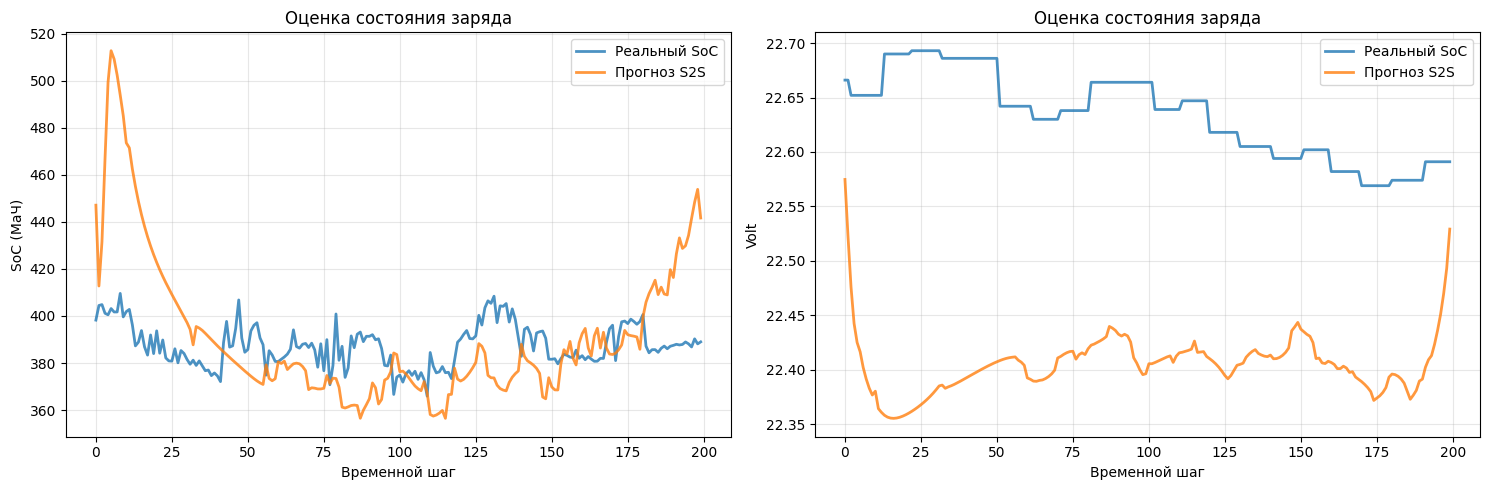

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(y_true_soc[512], label='Реальный SoC', linewidth=2, alpha=0.8)
plt.plot(y_pred_soc[512], label='Прогноз S2S', linewidth=2, alpha=0.8)
plt.xlabel('Временной шаг')
plt.ylabel('SoC (МаЧ)')
plt.title('Оценка состояния заряда')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(y_true_volt[512], label='Реальный SoC', linewidth=2, alpha=0.8)
plt.plot(y_pred_volt[512], label='Прогноз S2S', linewidth=2, alpha=0.8)
plt.xlabel('Временной шаг')
plt.ylabel('Volt')
plt.title('Оценка состояния заряда')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()